In [4]:
import os

# mapPath = '/lustre/scratch5/sprice/maps'
mapPath = '/Users/stephenprice/projects/CINS/ColdHarbor/maps'
os.chdir(mapPath)

print('current path: ', mapPath)

current path:  /Users/stephenprice/projects/CINS/ColdHarbor/maps


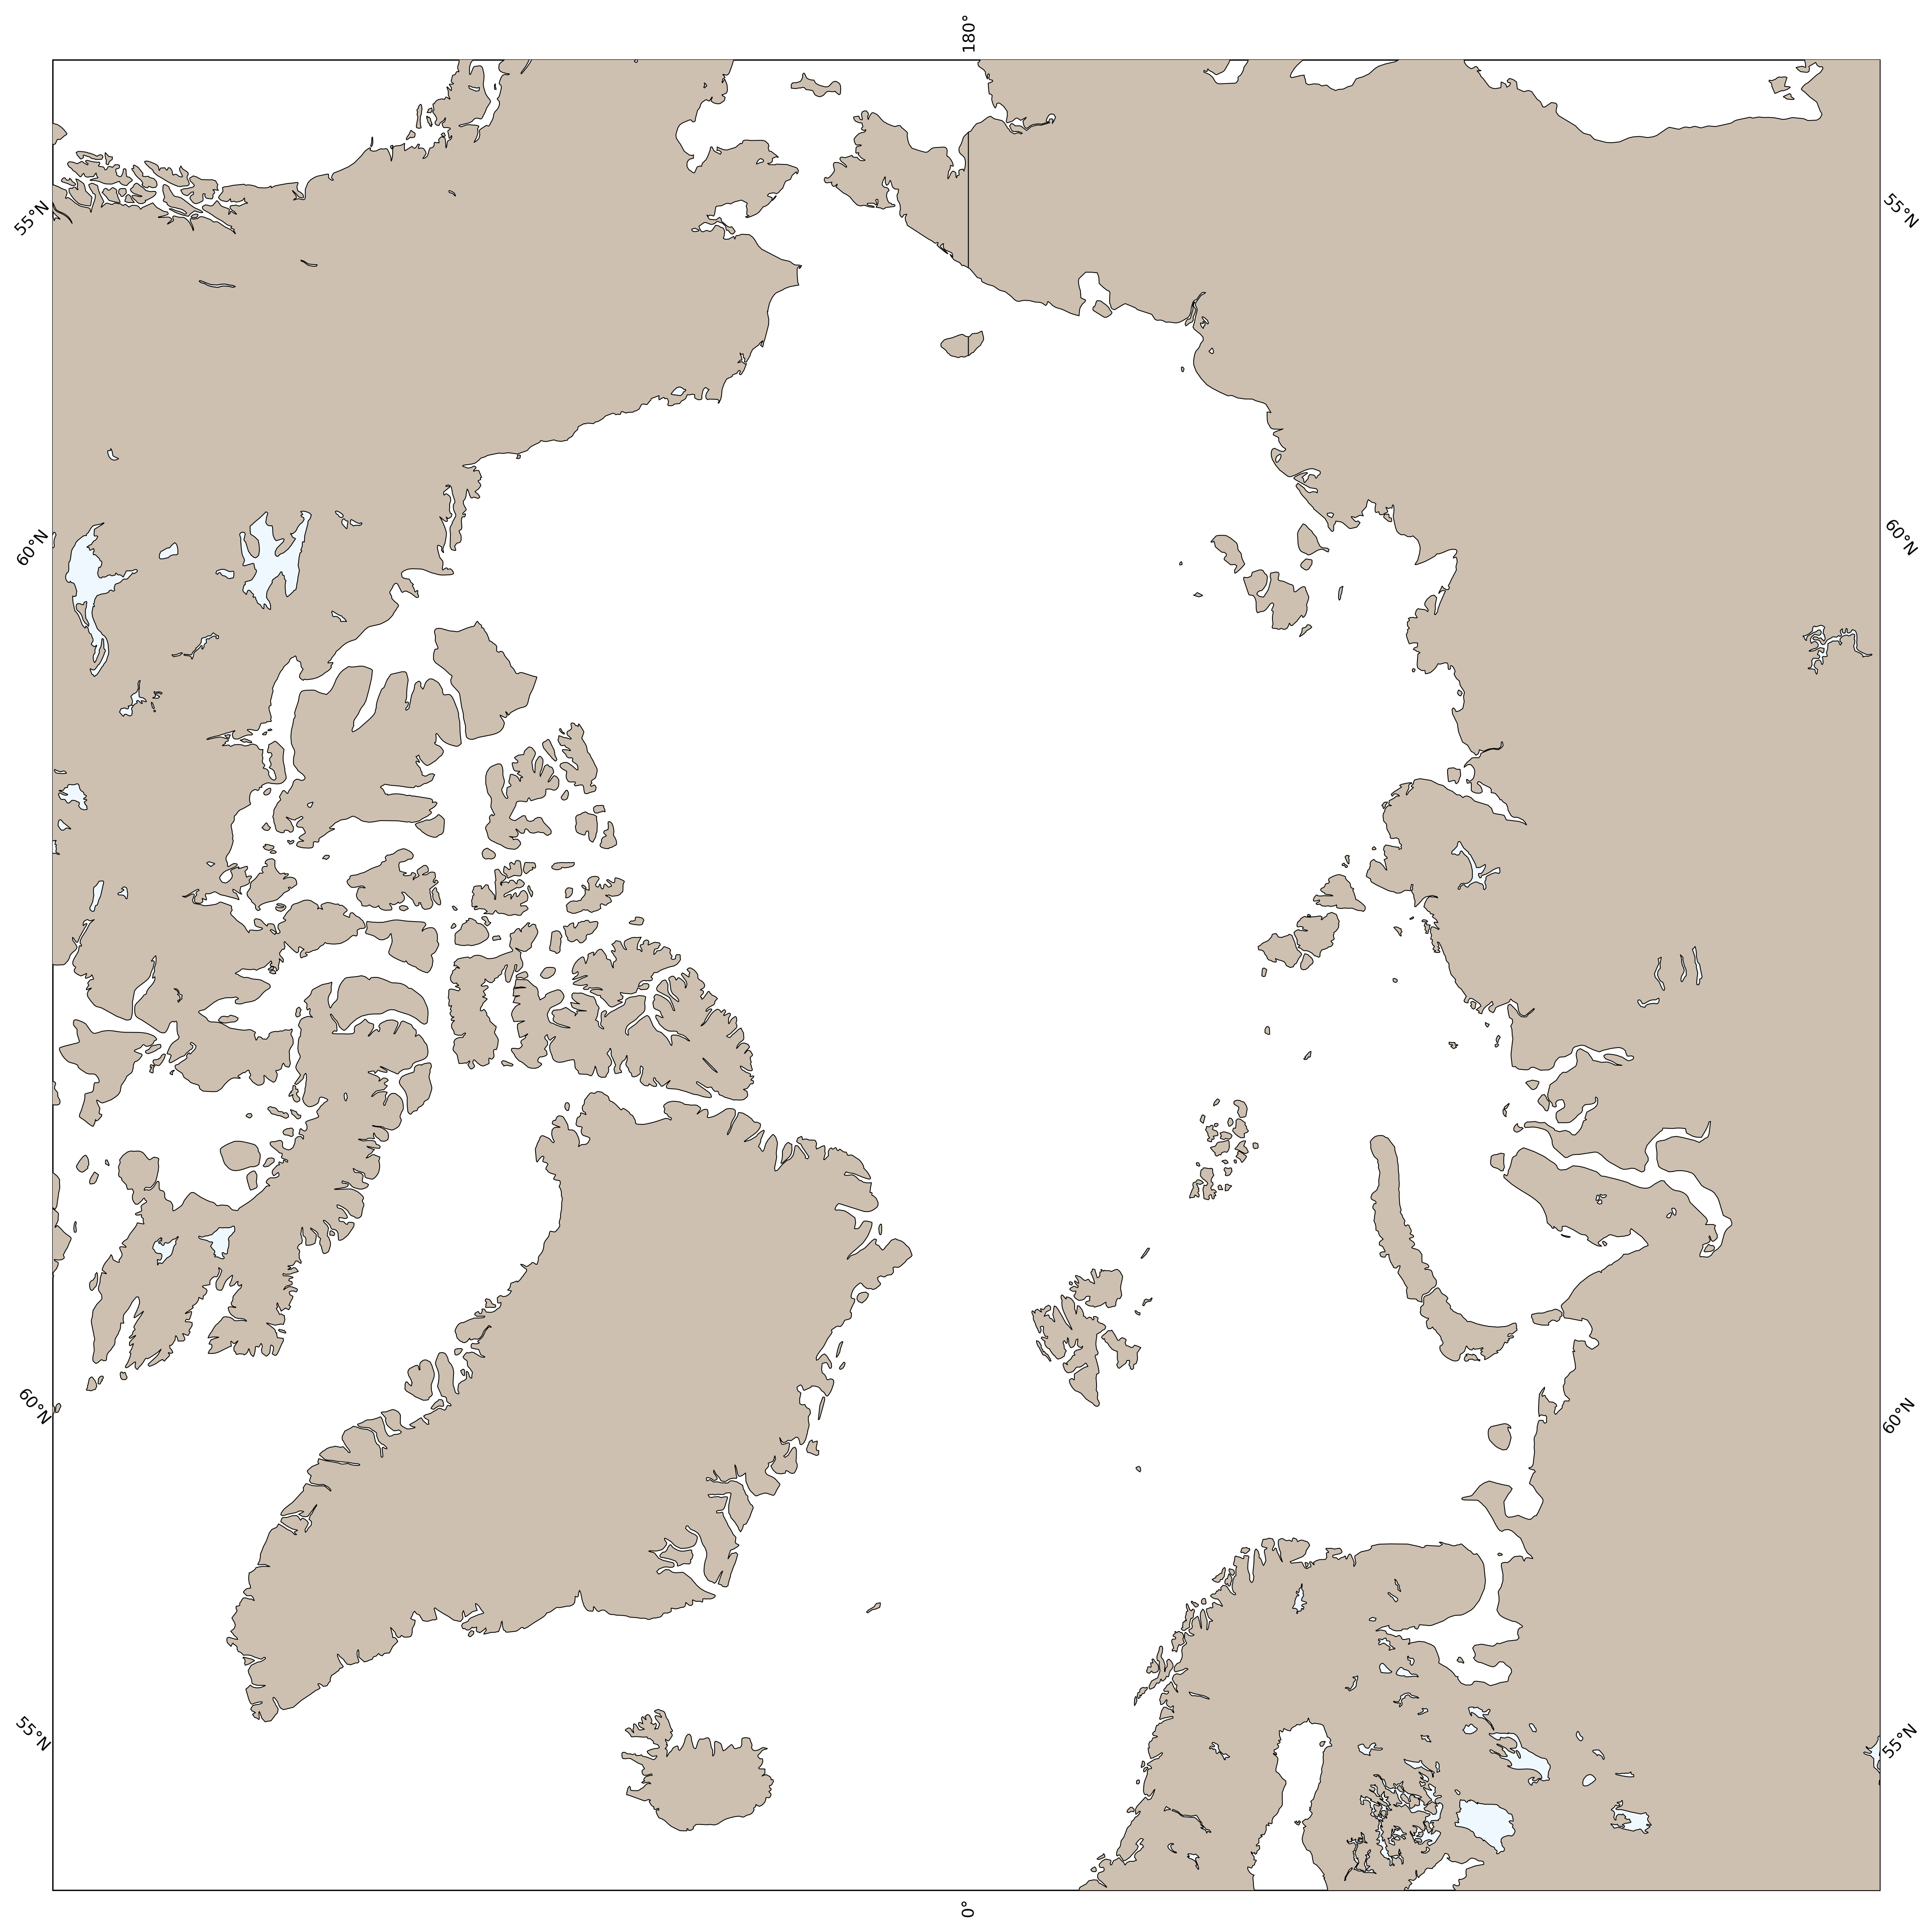

In [5]:
# insert figure here to overlay transect points w/ NN MPAS-SI mesh points

import os
from __future__ import absolute_import, division, print_function, \
    unicode_literals
import xarray as xr
import numpy as np
import numpy.ma as ma
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as cols
from matplotlib.pyplot import cm
from matplotlib.colors import from_levels_and_colors
from matplotlib.colors import BoundaryNorm
import matplotlib.path as mpath
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import cmocean
import shapely.geometry

from geometric_features.feature_collection import read_feature_collection
from common_functions import add_land_lakes_coastline


def _add_bbox(ax, bbox):
    # This plots parallel and meridian arcs using the 'bbox' information 
    # effectively making that the map boundary
    myProj = ccrs.PlateCarree()
    [ax_hdl] = ax.plot([bbox[0], bbox[1], bbox[1], bbox[0], bbox[0]],
                       [bbox[2], bbox[2], bbox[3], bbox[3], bbox[2]],
                       color='black', linewidth=0.5, marker='none',
                       transform=myProj)
    # Get the `Path` of the plot
    tx_path = ax_hdl._get_transformed_path()
    path_in_data_coords, _ = tx_path.get_transformed_path_and_affine()
    # Use the path's vertices to create a polygon
    polygon = mpath.Path(path_in_data_coords.vertices)
    ax.set_boundary(polygon)

bathyfile = './BedMachineAntarctica_v3_and_GEBCO_2023_0.0125_degree_20230831.nc'
featurefile = './arctic_regions_detailed.geojson'
transectfile = None
    
figdir = './'

clevels = [10, 50, 100, 150, 200, 400, 600, 800, 1000, 1200, 1400, 1800, 2200, 2600, 3000, 3500]
colormap = plt.get_cmap(cmocean.cm.deep)
colorIndices = np.int_(np.linspace(0, 255, num=len(clevels)+1, endpoint=True))
underColor = colormap(colorIndices[0])
overColor = colormap(colorIndices[-1])
colorIndices = colorIndices[1:-1]
colormap = cols.ListedColormap(colormap(colorIndices))
colormap.set_under(underColor)
colormap.set_over(overColor)
cnorm = mpl.colors.BoundaryNorm(clevels, colormap.N)

ds = xr.open_dataset(bathyfile)

# subsample = 4
subsample = 40

start = float(ds.lon.isel(lon=0).values)   # or ds.lon.values[0]
stop  = float(ds.lon.isel(lon=-1).values)  # or ds.lon.values[-1]
n     = int(ds.sizes["lon"] / subsample)   # more robust than ds.dims["lon"]

new_lat = np.linspace( start, stop, n, endpoint=True)
new_lon = np.linspace( start, stop, n, endpoint=True)

bathymetry = -ds.bathymetry.interp(lon=new_lon, lat=new_lat)

# Read in features
features = read_feature_collection(featurefile)
if transectfile is not None:
    transectfeatures = read_feature_collection(transectfile)
#print(dir(features))
#featureNames = [fc['properties']['name'] for fc in features.features]
#print(featureNames)

#featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Canada Basin', 'Canadian Archipelago', 'Eurasian Basin', 'Makarov Basin']
featuresToPlot = []
colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de', '#b2182b', '#80cdc1', '#a6dba0', '#9970ab', '#ffffbf', '#d6604d', '#2166ac']
color_names = ['dark blue', 'light red', 'dark green', 'light blue', 'dark red', 'aqua', 'light green', 'purple', 'lemon', 'light red', 'dark blue']

#featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Canada Basin', 'Canadian Archipelago']
##featuresToPlot = ['Barents Sea', 'Kara Sea', 'Laptev Sea', 'East Siberian Sea', 'Chukchi Sea', 'Beaufort Gyre', 'Beaufort Gyre Shelf', 'Canadian Archipelago']
#colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de', '#b2182b', '#80cdc1', '#a6dba0', '#9970ab', '#ffffbf']
#color_names = ['dark blue', 'light red', 'dark green', 'light blue', 'dark red', 'aqua', 'light green', 'purple', 'lemon']
#featuresToPlot = ['Norwegian Sea', 'Greenland Sea', 'Kara Sea', 'Eurasian Basin']
#featuresToPlot = ['Barents Sea']
#colors = ['#2166ac', '#d6604d', '#01665e', '#92c5de']
#color_names = ['dark blue', 'light red', 'dark green', 'light blue']
#color_names = ['dark blue']
#transectsToPlot = ['Iceland-Faroe-Scotland']

# The lat-lon proj
noProj = ccrs.PlateCarree()

# The projection of the map
mapProj = ccrs.NorthPolarStereo(central_longitude=0)

figsize = [20, 20]
figdpi = 300
extent = [-180, 180, 63, 90] # Arctic Ocean
#extent = [-50, 50, 58, 80] # Nordic Seas
plt.figure(figsize=figsize, dpi=figdpi)
ax = plt.axes(projection=mapProj)
add_land_lakes_coastline(ax)
ax.set_extent(extent, crs=noProj)
ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, color='w', linestyle=':', zorder=6)

# #log_norm = cols.LogNorm(vmin=np.min(bathymetry), vmax=np.max(bathymetry))
# log_norm = cols.LogNorm(vmin=10, vmax=3500)
# #cf = ax.pcolormesh(new_lon, new_lat, bathymetry, cmap=colormap, vmin=0, vmax=2500, transform=noProj)
# cf = ax.pcolormesh(new_lon, new_lat, bathymetry, cmap=colormap, transform=noProj, norm=log_norm)
# cbar = plt.colorbar(cf, ticks=clevels, boundaries=clevels, extend='both', shrink=0.4, pad=0.03, orientation='vertical')
# cbar.ax.tick_params(labelsize=14, labelcolor='black')
# cbar.set_label('[m]', fontsize=16)

fcIndex = 0
for fcname in featuresToPlot:
    for fc in features.features:
        if fc['properties']['name']==fcname:
            color = colors[fcIndex]
            geomType = fc['geometry']['type']
            shape = shapely.geometry.shape(fc['geometry'])
            props = {'linewidth': 2.0, 'edgecolor': color, 'alpha': 0.5, 'facecolor': color}
            ax.add_geometries((shape,), crs=noProj, **props)
            fcIndex = fcIndex+1
if transectfile is not None:
    fcIndex = 0
    for fcname in transectsToPlot:
        for fc in transectfeatures.features:
            if fc['properties']['name']==fcname:
                geomType = fc['geometry']['type']
                shape = shapely.geometry.shape(fc['geometry'])
                props = {'linewidth': 2, 'edgecolor': 'salmon', 'facecolor': 'None'}
                ax.add_geometries((shape,), crs=noProj, **props)
                fcIndex = fcIndex+1

plt.show()
# plt.savefig(f'{figdir}/ArcticSeaRegions.png', bbox_inches='tight')
# plt.close()